<a href="https://colab.research.google.com/github/GretelKMendez/Tareas-Mac-IA/blob/main/SVMIris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Precisión: 1.0


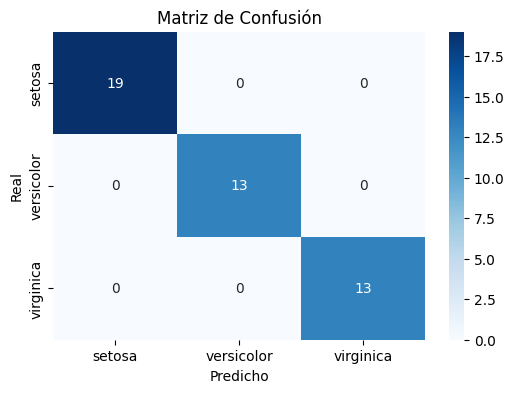


Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [3]:
# 1. Importar librerías
from sklearn.datasets import load_iris  #Dataset para clasificación (3 tipos de flores)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Cargar datos
iris = load_iris() #Guarda datos en un objeto tipo diccionario

# 3. Crear DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target  #Convierte a tabla
                            #target = tipo de flor (0,1,2)

# 4. Separar variables
X = df.drop('target', axis=1) #X → características
y = df['target']              # y → etiqueta

# 5. Dividir datos
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(    #Entrenamiento: 70% Prueba: 30%
    X, y, test_size=0.3, random_state=42                #
)

# 6. Crear modelo SVM
from sklearn.svm import SVC  #El modelo intenta encontrar: w⋅x+b=0

model = SVC(kernel='linear') #SVM con frontera lineal

# 7. Entrenar modelo
model.fit(X_train, y_train) #Aprende dónde dividir los datos

# 8. Hacer predicciones
y_pred = model.predict(X_test) #Predice nuevas observaciones

# 9. Evaluar modelo
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)  #interpretación:
                                          #1.0 → perfecto, 0.9 → muy bueno, <0.7 → malo
print("Precisión:", accuracy)

# 10. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 11. Visualizar matriz
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# 12. Reporte detallado
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

🔹 Precision

👉 De lo que predijo, cuánto fue correcto

🔹 Recall

👉 De los reales, cuántos detectó

🔹 F1-score

👉 Balance entre precision y recall

SVM busca separar datos con máxima distancia
Usa solo puntos clave (vectores de soporte)
Funciona muy bien en:
Clasificación
Datos con muchas variables

